# Step-by-Step GNN Fraud Detection Tutorial

This notebook turns your training script into a guided tutorial so you can learn and experiment interactively.

You will:
1. Load data (synthetic by default, Kaggle optional)
2. Build a k-nearest-neighbor transaction graph
3. Implement a simple GCN model in PyTorch
4. Train with class-imbalance handling
5. Evaluate with ROC-AUC and PR-AUC
6. Try your own experiments

## Step 0: Environment setup

If needed, run this once in your terminal (not in a notebook cell):

```powershell
python -m venv .venv
. .venv/Scripts/Activate.ps1
pip install -r requirements.txt
```

If you want to use Kaggle data, also configure `kaggle.json` at `%USERPROFILE%/.kaggle/kaggle.json`.

In [1]:
# Step 1: Imports
import random
import subprocess
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [2]:
# Step 2: Reproducibility helpers
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)
print("Seed set to 42")

Seed set to 42


## Step 3: Data loading functions

The notebook supports two sources:
- Kaggle dataset: `mlg-ulb/creditcardfraud`
- Synthetic fallback: generated transactions with rare fraud labels

In [3]:
def load_kaggle_creditcard(temp_dir: Path) -> pd.DataFrame:
    """Download and load Kaggle credit card fraud dataset if possible."""
    dataset = "mlg-ulb/creditcardfraud"
    cmd = [
        "kaggle",
        "datasets",
        "download",
        "-d",
        dataset,
        "-p",
        str(temp_dir),
        "--unzip",
        "-q",
    ]
    subprocess.run(cmd, check=True, capture_output=True, text=True)

    csv_path = temp_dir / "creditcard.csv"
    if not csv_path.exists():
        raise FileNotFoundError("Expected creditcard.csv after Kaggle download")

    return pd.read_csv(csv_path)


def make_synthetic_fraud(
    n_rows: int = 20000,
    n_features: int = 28,
    fraud_rate: float = 0.02,
) -> pd.DataFrame:
    """Create a synthetic transaction table with rare fraud labels."""
    rng = np.random.default_rng(42)
    y = (rng.random(n_rows) < fraud_rate).astype(np.int64)

    x_legit = rng.normal(0.0, 1.0, size=(n_rows, n_features))
    x_fraud = rng.normal(0.8, 1.2, size=(n_rows, n_features))
    x = np.where(y[:, None] == 1, x_fraud, x_legit)

    amount = np.exp(rng.normal(3.0 + 1.5 * y, 1.0, size=n_rows))
    time = np.sort(rng.integers(0, 172800, size=n_rows))

    cols = [f"V{i}" for i in range(1, n_features + 1)]
    df = pd.DataFrame(x, columns=cols)
    df.insert(0, "Time", time)
    df["Amount"] = amount
    df["Class"] = y
    return df

## Step 4: Choose data source and load data

Set `USE_KAGGLE = True` to try Kaggle first. If Kaggle loading fails, synthetic data will be used automatically.

In [12]:
# Step 4 config
USE_KAGGLE = True
SYNTHETIC_ROWS = 20000
SYNTHETIC_FRAUD_RATE = 0.02
MAX_ROWS = 25000
K_NEIGHBORS = 8
HIDDEN_DIM = 64
DROPOUT = 0.20
EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-4
LOG_EVERY = 5

source = "synthetic"
df = None

if USE_KAGGLE:
    try:
        with tempfile.TemporaryDirectory() as td:
            df = load_kaggle_creditcard(Path(td))
        source = "kaggle: mlg-ulb/creditcardfraud"
    except Exception as ex:
        print(f"[info] Kaggle load failed ({ex}). Falling back to synthetic data.")

if df is None:
    df = make_synthetic_fraud(
        n_rows=SYNTHETIC_ROWS,
        fraud_rate=SYNTHETIC_FRAUD_RATE,
    )

print(f"Data source: {source}")
print(f"Rows loaded: {len(df)}")
df.head()

Data source: kaggle: mlg-ulb/creditcardfraud
Rows loaded: 284807


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Step 5: Quick class balance check
class_counts = df["Class"].value_counts().sort_index()
class_ratio = df["Class"].mean()
print("Class counts (0=legit, 1=fraud):")
print(class_counts)
print(f"Fraud rate: {class_ratio:.4f}")

Class counts (0=legit, 1=fraud):
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.0017


## Step 6: Feature preparation

- Optionally subsample rows for faster iteration
- Split `Class` labels from numeric features
- Standardize features with `StandardScaler`

In [7]:
def prepare_features(df: pd.DataFrame, max_rows: int) -> tuple[np.ndarray, np.ndarray]:
    if max_rows > 0 and len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=42)

    if "Class" not in df.columns:
        raise ValueError("Dataset must include a 'Class' label column")

    y = np.array(df["Class"].to_numpy(dtype=np.int64), copy=True)
    x = np.array(df.drop(columns=["Class"]).to_numpy(dtype=np.float32), copy=True)

    scaler = StandardScaler()
    x = scaler.fit_transform(x)
    return x.astype(np.float32), y


x_np, y_np = prepare_features(df, max_rows=MAX_ROWS)
print(f"Feature matrix shape: {x_np.shape}")
print(f"Label shape: {y_np.shape}")

Feature matrix shape: (25000, 30)
Label shape: (25000,)


## Step 7: Build the graph using k-nearest neighbors

Each transaction is a node. We connect each node to its `k` nearest neighbors in feature space, then make edges undirected by adding both directions.

In [8]:
def build_knn_edges(x: np.ndarray, k_neighbors: int = 8) -> np.ndarray:
    nn_model = NearestNeighbors(n_neighbors=k_neighbors + 1, metric="euclidean")
    nn_model.fit(x)
    indices = nn_model.kneighbors(return_distance=False)

    src, dst = [], []
    for i, nbrs in enumerate(indices):
        for j in nbrs[1:]:  # skip self-neighbor
            src.append(i)
            dst.append(int(j))
            src.append(int(j))
            dst.append(i)

    edge_index = np.vstack([np.array(src), np.array(dst)])
    return edge_index


edges = build_knn_edges(x_np, k_neighbors=K_NEIGHBORS)
print(f"Edge index shape: {edges.shape}  (2 x num_edges)")
print(f"Approx edges per node (directed): {edges.shape[1] / len(x_np):.2f}")

Edge index shape: (2, 400000)  (2 x num_edges)
Approx edges per node (directed): 16.00


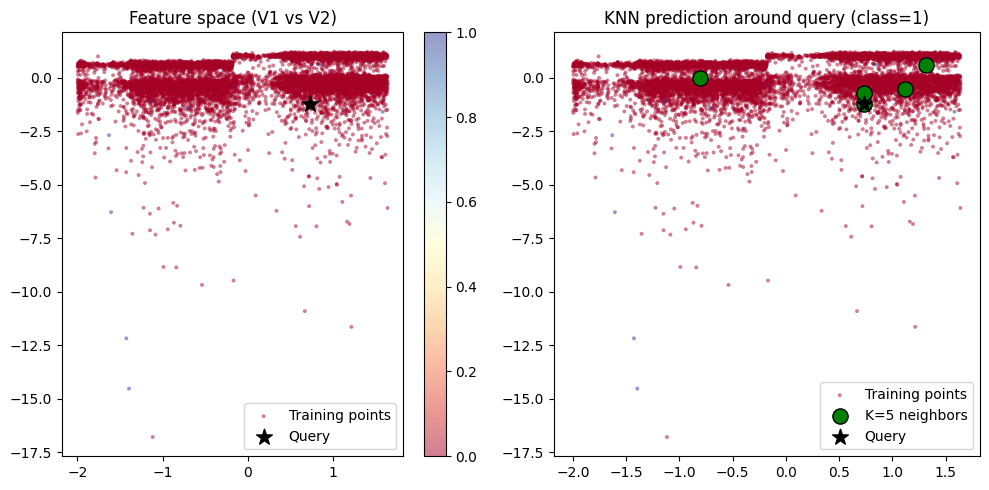

In [15]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

X = df.drop(columns=['Class'])
y = df['Class']

X_train, _, y_train, _ = train_test_split(
    X, y, test_size=0.7, stratify=y, random_state=42
)

# Reset indices so NumPy row positions and labels stay aligned
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_train_np = y_train.to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_scaled, y_train)

# Choose a fraud sample by POSITION (not DataFrame index label)
fraud_positions = np.flatnonzero(y_train_np == 1)
if len(fraud_positions) == 0:
    raise ValueError('No fraud samples found in training split.')

query_pos = np.random.choice(fraud_positions)
query = X_scaled[query_pos].reshape(1, -1)
distances, indices = knn.kneighbors(query, n_neighbors=5)

# Plot first 2 feature dimensions for a quick visualization
n_plot = min(10000, len(X_scaled))
plt.figure(figsize=(10, 5))
plt.subplot(121)
scatter = plt.scatter(
    X_scaled[:n_plot, 0],
    X_scaled[:n_plot, 1],
    c=y_train_np[:n_plot],
    cmap='RdYlBu',
    alpha=0.5,
    s=8,
    linewidths=0,
    rasterized=True,
    label='Training points',
)
plt.scatter(query[0, 0], query[0, 1], color='black', s=140, marker='*', label='Query')
plt.colorbar(scatter)
plt.title('Feature space (V1 vs V2)')
plt.legend(loc='best')

plt.subplot(122)
neighbors = X_scaled[indices[0]]
plt.scatter(
    X_scaled[:n_plot, 0],
    X_scaled[:n_plot, 1],
    c=y_train_np[:n_plot],
    cmap='RdYlBu',
    alpha=0.5,
    s=8,
    linewidths=0,
    rasterized=True,
    label='Training points',
)
plt.scatter(
    neighbors[:, 0],
    neighbors[:, 1],
    color='green',
    s=120,
    marker='o',
    edgecolors='black',
    label='K=5 neighbors',
)
plt.scatter(query[0, 0], query[0, 1], color='black', s=140, marker='*', label='Query')
pred_class = int(knn.predict(query)[0])
plt.title(f'KNN prediction around query (class={pred_class})')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Step 8: Compute normalized adjacency

We add self-loops and compute:

$$\hat{A} = D^{-1/2}(A + I)D^{-1/2}$$

This is the standard normalization used by GCNs.

In [ ]:
def normalized_adjacency(num_nodes: int, edge_index: np.ndarray) -> torch.Tensor:
    row, col = edge_index
    all_row = np.concatenate([row, np.arange(num_nodes)])
    all_col = np.concatenate([col, np.arange(num_nodes)])

    indices_t = torch.from_numpy(np.vstack([all_row, all_col]).astype(np.int64))
    values_t = torch.from_numpy(np.ones(len(all_row), dtype=np.float32))
    a = torch.sparse_coo_tensor(
        indices=indices_t,
        values=values_t,
        size=(num_nodes, num_nodes),
    ).coalesce()

    deg = torch.sparse.sum(a, dim=1).to_dense()
    deg_inv_sqrt = torch.pow(deg, -0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

    i = a.indices()
    v = a.values() * deg_inv_sqrt[i[0]] * deg_inv_sqrt[i[1]]
    return torch.sparse_coo_tensor(i, v, a.size()).coalesce()


a_hat = normalized_adjacency(num_nodes=len(y_np), edge_index=edges)
print(a_hat)

## Step 9: Define a simple GCN model

Architecture:
1. Graph propagation with $\hat{A}$
2. Linear layer + ReLU + Dropout
3. Another graph propagation
4. Final linear output (single logit for binary classification)

In [ ]:
class SimpleGCN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64, dropout: float = 0.2):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x: torch.Tensor, a_hat: torch.Tensor) -> torch.Tensor:
        h = torch.sparse.mm(a_hat, x)
        h = self.lin1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = torch.sparse.mm(a_hat, h)
        logits = self.lin2(h).squeeze(1)
        return logits

## Step 10: Train/validation/test masks

We use a stratified split: 70% train, 15% validation, 15% test.

In [ ]:
def build_masks(y: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    idx = np.arange(len(y))
    train_idx, temp_idx, y_train, y_temp = train_test_split(
        idx, y, test_size=0.30, random_state=42, stratify=y
    )
    val_idx, test_idx, _, _ = train_test_split(
        temp_idx, y_temp, test_size=0.50, random_state=42, stratify=y_temp
    )

    train_mask = np.zeros(len(y), dtype=bool)
    val_mask = np.zeros(len(y), dtype=bool)
    test_mask = np.zeros(len(y), dtype=bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask


train_mask, val_mask, test_mask = build_masks(y_np)
print(f"Train/Val/Test sizes: {train_mask.sum()}/{val_mask.sum()}/{test_mask.sum()}")

## Step 11: Train the model

Because fraud is rare, we use `BCEWithLogitsLoss` with `pos_weight = negatives / positives` to penalize missing fraud samples more strongly.

In [ ]:
def safe_roc_auc(y_true: np.ndarray, scores: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, scores))


x = torch.from_numpy(x_np)
y = torch.from_numpy(y_np).float()
train_mask_t = torch.from_numpy(train_mask)
val_mask_t = torch.from_numpy(val_mask)
test_mask_t = torch.from_numpy(test_mask)

model = SimpleGCN(in_dim=x.shape[1], hidden_dim=HIDDEN_DIM, dropout=DROPOUT)
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

pos = max(int(y_np.sum()), 1)
neg = max(len(y_np) - pos, 1)
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Using pos_weight = {pos_weight.item():.2f}")

history = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    opt.zero_grad()
    logits = model(x, a_hat)

    loss = criterion(logits[train_mask_t], y[train_mask_t])
    loss.backward()
    opt.step()

    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(logits[val_mask_t]).cpu().numpy()
        val_y = y_np[val_mask]
        val_auc = safe_roc_auc(val_y, val_probs)

    history.append((epoch, float(loss.item()), float(val_auc)))

    if epoch == 1 or epoch % LOG_EVERY == 0 or epoch == EPOCHS:
        print(f"epoch={epoch:03d} loss={loss.item():.4f} val_auc={val_auc:.4f}")

In [ ]:
# Step 12: Final test evaluation
model.eval()
with torch.no_grad():
    final_logits = model(x, a_hat)
    test_probs = torch.sigmoid(final_logits[test_mask_t]).cpu().numpy()

test_y = y_np[test_mask]
test_auc = safe_roc_auc(test_y, test_probs)
test_pr_auc = average_precision_score(test_y, test_probs)

print("[results]")
print(f"test_roc_auc={test_auc:.4f}")
print(f"test_pr_auc={test_pr_auc:.4f}")

In [ ]:
# Step 13: Inspect learning trend
history_df = pd.DataFrame(history, columns=["epoch", "loss", "val_auc"])
history_df.tail(10)

## Step 14: Try your own experiments

Change one parameter at a time, rerun from Step 4, and compare final metrics.

Suggested experiments:
1. Increase `K_NEIGHBORS` from 8 to 12
2. Reduce `DROPOUT` to 0.1
3. Increase `HIDDEN_DIM` to 128
4. Increase `EPOCHS` to 60
5. Increase `SYNTHETIC_FRAUD_RATE` to 0.05 and observe easier detection

Tip: Keep notes of `test_roc_auc` and `test_pr_auc` after each run.